# Regional model scorecard

A compact, ExtremeWeatherBench-style scorecard for daily-mean temperature and deterministic q95 hot-day forecasts. Cells show each model's **absolute** score; their color shows relative performance against the configured reference.

Hot days are ERA5 local-solar daily-mean temperatures above the ERA5 1991–2020 q95 threshold. For POD and FAR, every model is made deterministic by testing its forecast temperature against that same local-day threshold. `aifs_ens_v2` therefore uses its **ensemble-mean temperature**, not individual members or ensemble exceedance probability.

Definitions: POD = hits / (hits + misses); FAR = false alarms / (hits + false alarms). All regional statistics use cosine-latitude area weighting.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
from dask.diagnostics import ProgressBar

import heatextremes.verification.case_cache_reader as reader
from heatextremes.verification.alignment import map_to_forecast_grid


In [2]:
# --- Scorecard configuration: edit these lists/dictionaries as needed. ---
MODEL_NAMES = [
    'aifs_ens_v2',  # Reference: reader returns its ensemble-mean temperature.
    'aifs_v2',
    'aurora_e2s',
    'graphcast_e2s',
]
MODEL_LABELS = {
    'aifs_ens_v2': 'AIFS ENS\nv2 mean',
    'aifs_v2': 'AIFS v2',
    'aurora_e2s': 'Aurora',
    'graphcast_e2s': 'GraphCast',
}
REFERENCE_MODEL = 'aifs_ens_v2'

# Start in synthetic mode to workshop the figure locally. Set to 'real'
# to open/cache real model intermediates and calculate the same scorecard.
DATA_MODE = 'synthetic'  # 'synthetic' or 'real'
SYNTHETIC_SEED = 42

SCORECARD_METRICS = ['rmse_all', 'rmse_hot', 'pod', 'far']
FORECAST_DAYS = [0, 3, 6, 9, 12]
JJAS_MONTHS = [6, 7, 8, 9]
VALIDATION_YEARS = [2022, 2023, 2024, 2025]
CLIMATOLOGY_YEARS = list(range(1991, 2021))
LEGACY_AIFS_YEARS = [2022, 2023, 2024, 2025]

# One scorecard row per non-seam-crossing latitude/longitude box.
REGIONS = [
    {
        'name': 'East Africa',
        'bounds': {'latitude': (-15.0, 20.0), 'longitude': (25.0, 55.0)},
    },
    {
        'name': 'South Asia — India & Bangladesh',
        # Rectangular approximation around India and Bangladesh.
        'bounds': {'latitude': (6.0, 30.0), 'longitude': (68.0, 93.0)},
    },
]

# Use common initializations so every model is evaluated on the same dates.
# Set False only for exploratory, model-specific coverage diagnostics.
COMMON_INITIALIZATIONS = True

THRESHOLD_STORE = (
    '/net/monsoon/kylehall/ERA5/heat_extremes_climatology/'
    'thresholds/t2m_daily_mean_percentiles_1991_2020.zarr'
)
THRESHOLD_VARIABLE = 't2m_daily_mean_calendar_day_percentile'
# This store supplies the calendar-day (15-day rolling) climatological threshold.
THRESHOLD_PERCENTILE = 95.0

assert REFERENCE_MODEL in MODEL_NAMES
assert DATA_MODE in {'synthetic', 'real'}
assert all({'name', 'bounds'} <= set(region) for region in REGIONS)
assert set(SCORECARD_METRICS) <= {'rmse_all', 'rmse_hot', 'pod', 'far'}
assert all(0 <= day <= 14 for day in FORECAST_DAYS)


In [3]:
def coordinate_slice(coordinate, lower, upper):
    """Return a latitude/longitude slice for either coordinate direction."""
    return slice(lower, upper) if coordinate.values[0] < coordinate.values[-1] else slice(upper, lower)


def select_region(values, region):
    """Subset a non-seam-crossing latitude/longitude box."""
    return values.sel(
        latitude=coordinate_slice(values.latitude, *region['latitude']),
        longitude=coordinate_slice(values.longitude, *region['longitude']),
    )


def select_percentile(field, percentile):
    """Select a percentile regardless of the store's coordinate spelling."""
    for name in ('percentiles', 'percentile', 'quantile'):
        if name in field.dims or name in field.coords:
            return field.sel({name: percentile}, method='nearest', drop=True)
    return field


def local_day_threshold(lead, threshold):
    """Match the q95 threshold to each lead's longitude-specific valid date."""
    forecast = lead['forecast_temperature']
    threshold = map_to_forecast_grid(threshold, forecast, method='linear')
    valid_date = lead['valid_date']
    dayofyear = valid_date.dt.dayofyear.fillna(1).astype(np.int16)
    matched = threshold.sel(dayofyear=dayofyear).where(valid_date.notnull())
    return matched.transpose(*forecast.dims)


def regional_weights(values):
    return xr.DataArray(
        np.cos(np.deg2rad(values.latitude)),
        dims=('latitude',),
        coords={'latitude': values.latitude},
    )


def reduction_dims(values):
    return tuple(name for name in ('initialization', 'latitude', 'longitude') if name in values.dims)


def weighted_support(mask, weights):
    return weights.where(mask).sum(reduction_dims(mask), skipna=True)


def weighted_rmse(error, valid, weights):
    denominator = weighted_support(valid, weights)
    numerator = ((error ** 2) * weights).where(valid).sum(reduction_dims(error), skipna=True)
    return np.sqrt(numerator / denominator)


def score_one_lead(dataset, forecast_day, threshold, region):
    """Compute all requested scores for one model/lead in one Dask computation."""
    lead = select_region(dataset.sel(forecast_day=forecast_day), region)
    threshold = local_day_threshold(lead, threshold)
    weights = regional_weights(lead['forecast_temperature'])

    forecast = lead['forecast_temperature']
    observation = lead['observation_temperature']
    temperature_valid = lead['temperature_case_valid'].fillna(False).astype(bool)
    event_valid = lead['event_case_valid'].sel(event='hot_day_q95').fillna(False).astype(bool)
    observed_hot = lead['observed_event'].sel(event='hot_day_q95') > 0.5

    # POD/FAR deliberately use forecast temperature versus q95, including
    # for AIFS ENS v2: this is an ensemble-mean deterministic forecast.
    deterministic_valid = temperature_valid & event_valid & threshold.notnull()
    forecast_hot = forecast > threshold
    hit = deterministic_valid & forecast_hot & observed_hot
    miss = deterministic_valid & ~forecast_hot & observed_hot
    false_alarm = deterministic_valid & forecast_hot & ~observed_hot

    error = forecast - observation
    hot_temperature_valid = temperature_valid & event_valid & observed_hot
    result = xr.Dataset(
        {
            'rmse_all': weighted_rmse(error, temperature_valid, weights),
            'rmse_hot': weighted_rmse(error, hot_temperature_valid, weights),
            'pod': weighted_support(hit, weights) / (
                weighted_support(hit, weights) + weighted_support(miss, weights)
            ),
            'far': weighted_support(false_alarm, weights) / (
                weighted_support(hit, weights) + weighted_support(false_alarm, weights)
            ),
            'all_cases': temperature_valid.sum(reduction_dims(temperature_valid)),
            'hot_cases': hot_temperature_valid.sum(reduction_dims(hot_temperature_valid)),
            'binary_cases': deterministic_valid.sum(reduction_dims(deterministic_valid)),
        }
    )
    with ProgressBar():
        return result.compute()


def hot_day_frequency_change(daily_temperature, threshold, region):
    """Observed JJAS hot-day-frequency change, validation versus climatology."""
    temperature = select_region(daily_temperature, region)
    threshold = map_to_forecast_grid(threshold, temperature, method='linear')
    threshold_by_day = threshold.sel(dayofyear=temperature.time.dt.dayofyear)
    observed_hot = temperature > threshold_by_day
    validation = observed_hot.where(
        temperature.time.dt.year.isin(VALIDATION_YEARS)
        & temperature.time.dt.month.isin(JJAS_MONTHS)
    ).mean('time', skipna=True)
    climatology = observed_hot.where(
        temperature.time.dt.year.isin(CLIMATOLOGY_YEARS)
        & temperature.time.dt.month.isin(JJAS_MONTHS)
    ).mean('time', skipna=True)
    return (100 * (validation / climatology - 1)).rename('hot_day_frequency_change')


In [4]:
# The reader opens Zarr metadata lazily and reports missing month/lead slices.
datasets = {}
threshold_source = None
threshold_q95 = None
daily_temperature_source = None
era5_daily_temperature = None

if DATA_MODE == 'real':
    for model_name in MODEL_NAMES:
        print(f'Opening {model_name}…', flush=True)
        kwargs = {'forecast_days': FORECAST_DAYS}
        if model_name.casefold() in reader.LEGACY_AIFS_MODEL_NAMES:
            kwargs.update(years=LEGACY_AIFS_YEARS, months=JJAS_MONTHS)
        dataset = reader.open_model_intermediates(model_name, **kwargs)
        datasets[model_name] = dataset.sel(
            initialization=dataset.initialization.dt.month.isin(JJAS_MONTHS)
        )

    if COMMON_INITIALIZATIONS:
        common_initializations = datasets[MODEL_NAMES[0]].initialization.values
        for model_name in MODEL_NAMES[1:]:
            common_initializations = np.intersect1d(
                common_initializations, datasets[model_name].initialization.values
            )
        if not len(common_initializations):
            raise ValueError(
                'The selected models have no common initialization dates. '
                'Inspect their inventories or set COMMON_INITIALIZATIONS=False for coverage diagnostics.'
            )
        print(f'Using {len(common_initializations)} common JJAS initializations.', flush=True)
        datasets = {
            model_name: dataset.sel(initialization=common_initializations)
            for model_name, dataset in datasets.items()
        }

    threshold_source = xr.open_zarr(THRESHOLD_STORE, consolidated=True, chunks='auto')
    threshold_q95 = select_percentile(
        threshold_source[THRESHOLD_VARIABLE], THRESHOLD_PERCENTILE
    )
    daily_temperature_source = xr.open_zarr(
        reader.DEFAULT_ERA5_DAILY_TEMPERATURE_STORE, consolidated=True, chunks='auto'
    )
    era5_daily_temperature = daily_temperature_source['t2m_daily_mean']
else:
    print('Synthetic mode: skipping intermediate-reader and ERA5 access.', flush=True)


Synthetic mode: skipping intermediate-reader and ERA5 access.


In [5]:
def synthetic_scorecard(seed):
    """Create fixed, plausible score patterns solely for layout work."""
    rng = np.random.default_rng(seed)
    baseline = {
        'rmse_all': np.linspace(1.6, 4.2, len(FORECAST_DAYS)),
        'rmse_hot': np.linspace(1.9, 4.8, len(FORECAST_DAYS)),
        'pod': np.linspace(0.78, 0.46, len(FORECAST_DAYS)),
        'far': np.linspace(0.18, 0.43, len(FORECAST_DAYS)),
    }
    # Relative skill versus AIFS ENS v2 mean: negative is better for
    # lower-is-better metrics; positive is better for POD.
    relative_skill = {
        'aifs_ens_v2': 0.00,
        'aifs_v2': -0.06,
        'aurora_e2s': 0.05,
        'graphcast_e2s': -0.02,
    }
    rows = []
    for region_index, region in enumerate(REGIONS):
        for model_name in MODEL_NAMES:
            for lead_index, forecast_day in enumerate(FORECAST_DAYS):
                skill = relative_skill.get(model_name, 0.0) + rng.normal(0, 0.025)
                row = {
                    'region': region['name'],
                    'model': model_name,
                    'model_label': MODEL_LABELS.get(model_name, model_name),
                    'forecast_day': forecast_day,
                    'all_cases': int(42000 - 4500 * region_index - 900 * lead_index),
                    'hot_cases': int(2200 - 300 * region_index - 80 * lead_index),
                    'binary_cases': int(41500 - 4500 * region_index - 900 * lead_index),
                }
                for metric in SCORECARD_METRICS:
                    value = baseline[metric][lead_index]
                    if metric.startswith('rmse'):
                        value *= 1 + 0.12 * region_index
                    elif metric == 'pod':
                        value *= 1 - 0.05 * region_index
                    else:
                        value *= 1 + 0.12 * region_index
                    value *= 1 + skill
                    row[metric] = float(np.clip(value, 0.01, 0.99) if metric in {'pod', 'far'} else value)
                rows.append(row)
    return pd.DataFrame(rows).sort_values(['region', 'model', 'forecast_day'])


def synthetic_hot_day_frequency_change(seed):
    """Create toy observed hot-day-frequency changes, in percent."""
    rng = np.random.default_rng(seed + 1)
    fields = {}
    for index, region in enumerate(REGIONS):
        bounds = region['bounds']
        latitude = np.linspace(*bounds['latitude'], 42)
        longitude = np.linspace(*bounds['longitude'], 50)
        lon, lat = np.meshgrid(longitude, latitude)
        broad_pattern = (
            20 * np.sin((lon - longitude.mean()) / 6)
            + 13 * np.cos((lat - latitude.mean()) / 5)
            + 8 * index
        )
        noise = rng.normal(0, 4, size=broad_pattern.shape)
        fields[region['name']] = xr.DataArray(
            broad_pattern + noise,
            dims=('latitude', 'longitude'),
            coords={'latitude': latitude, 'longitude': longitude},
            name='hot_day_frequency_change',
            attrs={
                'long_name': 'Observed hot-day frequency change',
                'units': '%',
                'definition': '100 * (2022–2025 JJAS exceedance frequency / 1991–2020 JJAS exceedance frequency - 1)',
            },
        )
    return fields


if DATA_MODE == 'synthetic':
    scorecard = synthetic_scorecard(SYNTHETIC_SEED)
    frequency_change_maps = synthetic_hot_day_frequency_change(SYNTHETIC_SEED)
else:
    # One bounded computation per model and lead keeps memory use predictable.
    score_rows = []
    for region in REGIONS:
        for model_name, dataset in datasets.items():
            for forecast_day in FORECAST_DAYS:
                print(f"Computing {region['name']}: {model_name}, forecast day {forecast_day}…", flush=True)
                result = score_one_lead(dataset, forecast_day, threshold_q95, region['bounds'])
                score_rows.append(
                    {
                        'region': region['name'],
                        'model': model_name,
                        'model_label': MODEL_LABELS.get(model_name, model_name),
                        'forecast_day': forecast_day,
                        **{name: float(result[name]) for name in SCORECARD_METRICS},
                        'all_cases': int(result['all_cases']),
                        'hot_cases': int(result['hot_cases']),
                        'binary_cases': int(result['binary_cases']),
                    }
                )
    scorecard = pd.DataFrame(score_rows).sort_values(['region', 'model', 'forecast_day'])
    frequency_change_maps = {
        region['name']: hot_day_frequency_change(
            era5_daily_temperature, threshold_q95, region['bounds']
        )
        for region in REGIONS
    }

scorecard


,region,model,model_label,forecast_day,all_cases,hot_cases,binary_cases,rmse_all,rmse_hot,pod,far
0,East Africa,aifs_ens_v2,AIFS ENS v2 mean,0,42000,2200,41500,1.612189,1.914474,0.785942,0.181371
1,East Africa,aifs_ens_v2,AIFS ENS v2 mean,3,41100,2120,40600,2.191501,2.556751,0.681800,0.236195
2,East Africa,aifs_ens_v2,AIFS ENS v2 mean,6,40200,2040,39700,2.954408,3.412850,0.631632,0.310722
3,East Africa,aifs_ens_v2,AIFS ENS v2 mean,9,39300,1960,38800,3.633475,4.170820,0.552698,0.376141
4,East Africa,aifs_ens_v2,AIFS ENS v2 mean,12,38400,1880,37900,3.995141,4.565876,0.437563,0.409026
5,East Africa,aifs_v2,AIFS v2,0,42000,2200,41500,1.451913,1.724146,0.707807,0.163340
6,East Africa,aifs_v2,AIFS v2,3,41100,2120,40600,2.122191,2.475890,0.660237,0.228725
7,East Africa,aifs_v2,AIFS v2,6,40200,2040,39700,2.703072,3.122515,0.577898,0.284289
8,East Africa,aifs_v2,AIFS v2,9,39300,1960,38800,3.335509,3.828788,0.507373,0.345296
9,East Africa,aifs_v2,AIFS v2,12,38400,1880,37900,3.858430,4.409635,0.422590,0.395030


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


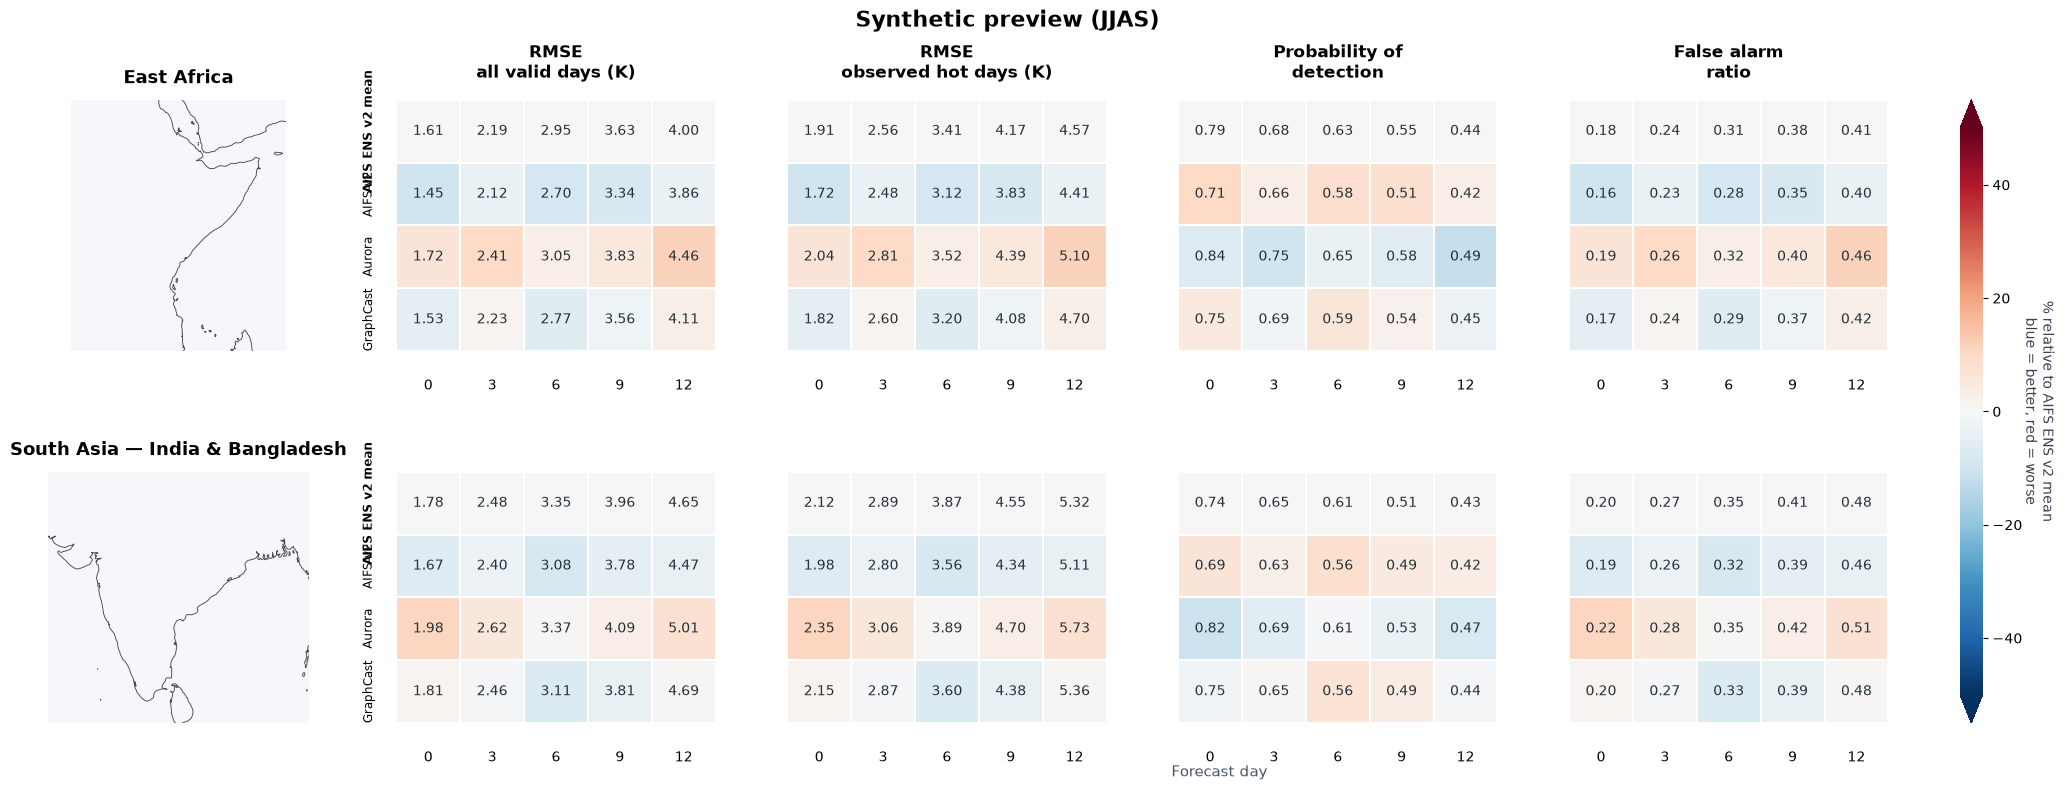

In [6]:
METRIC_TITLES = {
    'rmse_all': 'RMSE (All)',
    'rmse_hot': 'RMSE (Hot Days)',
    'pod': 'POD',
    'far': 'FAR',
}


def format_value(metric, value):
    if not np.isfinite(value):
        return '—'
    return f'{value:.2f}'


def plot_scorecard(frame, frequency_change_maps):
    map_norm = TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)
    map_cmap = plt.colormaps['RdBu_r'].copy()
    map_cmap.set_bad('#e5e7eb')

    figure = plt.figure(
        figsize=(8.5 + 3.35 * len(SCORECARD_METRICS), 1.45 + 3.15 * len(REGIONS)),
        facecolor='white',
    )
    grid = figure.add_gridspec(
        len(REGIONS), len(SCORECARD_METRICS) + 2,
        width_ratios=[1.50, *([1.52] * len(SCORECARD_METRICS)), 0.12],
        wspace=0.37, hspace=0.45,
    )

    map_image = None
    for region_index, region in enumerate(REGIONS):
        region_name = region['name']
        region_frame = frame.loc[frame.region.eq(region_name)]
        bounds = region['bounds']

        map_axis = figure.add_subplot(grid[region_index, 0], projection=ccrs.PlateCarree())
        map_axis.set_extent([*bounds['longitude'], *bounds['latitude']], crs=ccrs.PlateCarree())
        map_axis.set_facecolor('#f5f7fa')
        map_image = frequency_change_maps[region_name].plot.pcolormesh(
            ax=map_axis, transform=ccrs.PlateCarree(), cmap=map_cmap, norm=map_norm,
            add_colorbar=False, rasterized=True,
        )
        map_axis.coastlines(color='#4a4a4a', linewidth=0.65)
        map_axis.spines['geo'].set_visible(True)
        map_axis.spines['geo'].set_color('black')
        map_axis.spines['geo'].set_linewidth(0.8)

        for column, metric in enumerate(SCORECARD_METRICS, start=1):
            axis = figure.add_subplot(grid[region_index, column])
            values = (
                region_frame.pivot(index='model', columns='forecast_day', values=metric)
                .reindex(index=MODEL_NAMES, columns=FORECAST_DAYS)
            )
            axis.set_facecolor('#edf2f7')
            axis.set_xlim(-0.5, len(FORECAST_DAYS) - 0.5)
            axis.set_ylim(len(MODEL_NAMES) - 0.5, -0.5)
            if region_index == 0:
                axis.set_title(METRIC_TITLES[metric], fontsize=12, fontweight='semibold', pad=16)
            axis.set_xticks(range(len(FORECAST_DAYS)), FORECAST_DAYS, fontsize=10)
            axis.set_yticks(range(len(MODEL_NAMES)))
            axis.set_yticklabels(
                [MODEL_LABELS.get(name, name) for name in MODEL_NAMES] if column == 1 else [],
                fontsize=9, rotation=0, va='center', ha='right',
            )
            axis.tick_params(axis='x', length=0, pad=3)
            axis.tick_params(axis='y', length=0, pad=8)
            for label, model_name in zip(axis.get_yticklabels(), MODEL_NAMES):
                if model_name == REFERENCE_MODEL:
                    label.set_fontweight('bold')
            for spine in axis.spines.values():
                spine.set_visible(False)
            axis.set_xticks(np.arange(-0.5, len(FORECAST_DAYS), 1), minor=True)
            axis.set_yticks(np.arange(-0.5, len(MODEL_NAMES), 1), minor=True)
            axis.grid(which='minor', color='white', linewidth=1.5)
            axis.tick_params(which='minor', bottom=False, left=False)

            for row in range(len(MODEL_NAMES)):
                for lead_index in range(len(FORECAST_DAYS)):
                    value = values.iloc[row, lead_index]
                    axis.text(lead_index, row, format_value(metric, value), ha='center', va='center',
                              color='#263238', fontsize=10)

    colorbar = figure.colorbar(map_image, cax=figure.add_subplot(grid[:, -1]), extend='both')
    colorbar.outline.set_visible(False)
    colorbar.set_label(
        'Observed 15-day-q95 exceedance-frequency change (%)\nJJAS 2022–2025 relative to 1991–2020',
        rotation=270, labelpad=25, color='#374151',
    )
    title = 'Synthetic preview' if DATA_MODE == 'synthetic' else 'Daily-temperature and hot-day scorecards'
    figure.suptitle(f'{title} (JJAS)', fontsize=16, fontweight='semibold', y=0.97)
    figure.subplots_adjust(top=0.86, bottom=0.08, left=0.04, right=0.96)
    plt.show()


plot_scorecard(scorecard, frequency_change_maps)


In [7]:
# Always inspect support before comparing small-sample hot-day scores.
support_columns = ['region', 'model_label', 'forecast_day', 'all_cases', 'hot_cases', 'binary_cases']
display(scorecard[support_columns].sort_values(['region', 'model_label', 'forecast_day']))

# Optional: save the exact numbers that produced the figure.
# scorecard.to_csv('regional_model_scorecard.csv', index=False)

# Close lazy source handles once this notebook no longer needs them.
# if threshold_source is not None:
#     threshold_source.close()
# if daily_temperature_source is not None:
#     daily_temperature_source.close()
# for dataset in datasets.values():
#     dataset.close()


,region,model_label,forecast_day,all_cases,hot_cases,binary_cases
0,East Africa,AIFS ENS v2 mean,0,42000,2200,41500
1,East Africa,AIFS ENS v2 mean,3,41100,2120,40600
2,East Africa,AIFS ENS v2 mean,6,40200,2040,39700
3,East Africa,AIFS ENS v2 mean,9,39300,1960,38800
4,East Africa,AIFS ENS v2 mean,12,38400,1880,37900
5,East Africa,AIFS v2,0,42000,2200,41500
6,East Africa,AIFS v2,3,41100,2120,40600
7,East Africa,AIFS v2,6,40200,2040,39700
8,East Africa,AIFS v2,9,39300,1960,38800
9,East Africa,AIFS v2,12,38400,1880,37900
